In [1]:
# import features
import pandas as pd
# acitvity entropy
df_entropy = pd.read_csv('../output/data_cleaned/activity_entropy_rates.csv')
print(df_entropy.shape)

# early warning scores (physiological)
df_EWS = pd.read_csv('../output/data_cleaned/Mian_warning_score.csv')
df_EWS.columns = ['patient_id', 'date', 'early_warning_score']


# sleep quality
df_sleep_quality = pd.read_csv('../output/sleep_score/sleep_quality_score_by_duration.csv')
df_sleep_quality = df_sleep_quality.drop(columns= ['sum', 'scaled_sleep_quality_mean','scaled_sleep_quality_sum']).copy()
df_sleep_quality.columns = ['patient_id', 'date', 'sleep_quality_score']

# agitation
df_agitation = pd.read_csv('../output/data_cleaned/agitation_daily_counts.csv')

# uti
df_uti = pd.read_csv('../output/data_cleaned/uti_daily.csv')

merged_df = df_entropy
# merge dataframes
for df in [df_EWS, df_sleep_quality, df_agitation, df_uti]:
    print(df.shape)
    merged_df = pd.merge(merged_df, df, on=['patient_id', 'date'], how='outer')

# only consider the patients without NA in the following analysis (as the analysis itself will be individualized anyway)
# analysis_df = merged_df.dropna(subset=['sleep_quality_score']).dropna(subset=['early_warning_score']).dropna(subset=['entropy_rate']).copy()
analysis_df = merged_df.dropna(subset=['sleep_quality_score']).copy()
# fill uti and agitation none/NA as 0
cols = ['agitation_counts', 'uti_happen']
analysis_df[cols] = analysis_df[cols].fillna(0)
print(analysis_df.shape)
analysis_df.columns = ['patient_id', 'date', 'entropy rate', 'early warning score', 'sleep quality score', 'agitation counts', 'uti counts']
analysis_df

(2722, 3)
(2160, 3)
(800, 3)
(115, 3)
(265, 3)
(800, 7)


,patient_id,date,entropy rate,early warning score,sleep quality score,agitation counts,uti counts
222,0f352,2019-06-26,0.669008,0.0,0.142857,0.0,1.0
223,0f352,2019-06-27,0.653618,NaN,1.200000,0.0,0.0
224,0f352,2019-06-28,0.613697,0.0,0.416667,0.0,0.0
225,0f352,2019-06-29,0.615494,0.0,1.000000,0.0,1.0
226,0f352,2019-06-30,0.514768,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...
2798,f220c,2019-06-22,0.608841,0.0,0.000000,0.0,0.0
2800,f220c,2019-06-24,0.600492,NaN,0.000000,0.0,0.0
2801,f220c,2019-06-25,0.518683,NaN,1.400000,0.0,0.0
2802,f220c,2019-06-26,0.621802,NaN,0.500000,0.0,0.0


In [2]:
if_results = pd.read_csv("../output/Anomaly_delirium_Revised/FI_anomaly_labels.csv")
anomaly_events = if_results[if_results['anomaly_label'] == -1][
    ['patient_id', 'test_date']
].reset_index(drop=True)
anomaly_events.columns = ['patient_id', 'date']

non_anomaly_events = if_results[if_results['anomaly_label'] == 1][
    ['patient_id', 'test_date']
].reset_index(drop=True)
non_anomaly_events.columns = ['patient_id', 'date']

print(anomaly_events.shape)
print(non_anomaly_events.shape)
anomaly_events


(77, 2)
(415, 2)


,patient_id,date
0,1fbe4,2019-05-08
1,1fbe4,2019-05-11
2,1fbe4,2019-05-27
3,1fbe4,2019-05-28
4,1fbe4,2019-06-02
...,...,...
72,ec812,2019-04-22
73,ec812,2019-04-26
74,ec812,2019-05-21
75,ec812,2019-06-03


In [3]:
data_anomaly  = pd.merge(analysis_df, anomaly_events, on=["patient_id", "date"], how="right").reset_index(drop = True).drop(["patient_id", "date"], axis=1)
data_non_anomaly  = pd.merge(analysis_df, non_anomaly_events, on=["patient_id", "date"], how="right").reset_index(drop = True).drop(["patient_id", "date"], axis=1)

print(data_anomaly.shape)
print(data_non_anomaly.shape)
data_anomaly

(77, 5)
(415, 5)


,entropy rate,early warning score,sleep quality score,agitation counts,uti counts
0,0.643295,0.0,1.200000,0.0,0.0
1,0.609564,1.0,1.100000,0.0,1.0
2,0.592326,0.0,1.000000,0.0,0.0
3,0.576205,0.0,0.900000,0.0,0.0
4,0.661185,1.0,1.666667,0.0,1.0
...,...,...,...,...,...
72,0.595762,1.0,1.375000,0.0,0.0
73,0.690293,1.0,1.375000,0.0,1.0
74,0.724717,0.0,1.285714,0.0,0.0
75,0.630114,0.0,0.777778,0.0,0.0


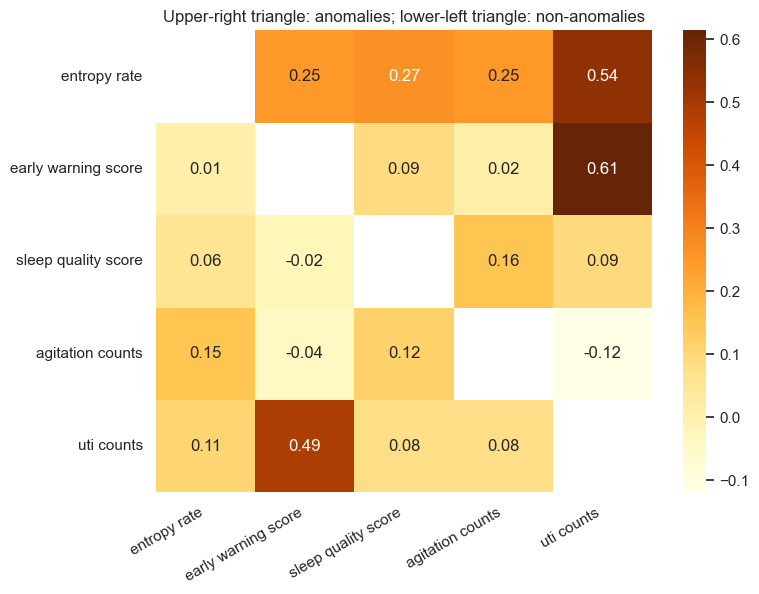

In [4]:
import seaborn as sns
sns.set_theme(style="white")
# calculate corr
# method_use = "pearson"
# method_use = "kendall"
method_use = "spearman"
correlation_matrix_anomaly = data_anomaly.corr(method=method_use)
correlation_matrix_NONanomaly = data_non_anomaly.corr(method=method_use)


##### prepare matrix for plotting
import numpy as np
# Step 1: Create a square matrix filled with NaN values or zeros
n = len(correlation_matrix_anomaly)  # Assuming both matrices have the same shape
combined_corr_matrix = np.zeros((n, n))
# lower (tril)
combined_corr_matrix[np.tril_indices(n, 0)] = correlation_matrix_NONanomaly.values[np.tril_indices(n, 0)]
#upper (triu)
combined_corr_matrix[np.triu_indices(n, 0)] = correlation_matrix_anomaly.values[np.triu_indices(n, 0)]


combined_corr_matrix_df_raw = pd.DataFrame(combined_corr_matrix, columns=correlation_matrix_anomaly.columns, index=correlation_matrix_anomaly.columns)
df_copy =combined_corr_matrix_df_raw.copy()


arr = df_copy.to_numpy().copy()
np.fill_diagonal(arr, np.nan)
combined_corr_matrix_df = pd.DataFrame(arr, index=df_copy.index, columns=df_copy.columns)

# Visualize the result (if needed)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(combined_corr_matrix_df, annot=True, cmap="YlOrBr", fmt=".2f")
plt.title("Upper-right triangle: anomalies; lower-left triangle: non-anomalies")
plt.xticks(rotation=30, ha='right')

plt.savefig('../output/Anomaly_delirium_Revised/corr_compare.png', dpi=300, bbox_inches="tight")

plt.show()